# Indoor WiFi Localization using Machine Learning

## Author
**Moaz Abeer**

## Project

This project develops an indoor indoor positioning system using WiFi fingerprinting and machine learning. The dataset is collected using the WiFi Heatmap Analyzer application, transformed into WiFi fingerprints, and used to train multiple machine learning models for predicting indoor locations.

---

## Objectives

- Load WiFi scan data
- Validate and clean the dataset
- Generate WiFi fingerprints
- Perform exploratory data analysis
- Train multiple ML models
- Compare model performance
- Save the best model
- Predict user location from new WiFi scans

---

## Workflow

1. Project Setup
2. Data Loading
3. Data Validation
4. Exploratory Data Analysis
5. Fingerprint Generation
6. Feature Engineering
7. Model Training
8. Model Evaluation
9. Model Comparison
10. Save Best Model
11. Live Prediction

# Section 1 — Project Setup

In [1]:
# ==========================================================
# Section 1 - Import Libraries
# ==========================================================

import os
import glob
import zipfile
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [2]:
# ==========================================================
# Reproducibility
# ==========================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"✅ Random seed set to {RANDOM_STATE}")

✅ Random seed set to 42


In [3]:
# ==========================================================
# Environment Information
# ==========================================================

import sklearn

print("Python Libraries")
print("---------------------------")
print(f"Pandas       : {pd.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"Scikit-learn : {sklearn.__version__}")

Python Libraries
---------------------------
Pandas       : 2.2.2
NumPy        : 2.0.2
Scikit-learn : 1.6.1


# Section 2 — Data Loading

In [4]:
# ==========================================================
# Upload Dataset
# ==========================================================

print("Please upload your ZIP dataset.")

uploaded = files.upload()

Please upload your ZIP dataset.


Saving project output csv files from version 1.zip to project output csv files from version 1.zip


In [5]:
# ==========================================================
# Extract ZIP File
# ==========================================================

zip_filename = list(uploaded.keys())[0]
extract_folder = "wifi_dataset"

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print(f"✅ Dataset extracted to '{extract_folder}'")

✅ Dataset extracted to 'wifi_dataset'


In [6]:
# ==========================================================
# Locate CSV Files
# ==========================================================

csv_files = glob.glob(
    os.path.join(extract_folder, "**", "*.csv"),
    recursive=True
)

print(f"📁 CSV files found: {len(csv_files)}")

📁 CSV files found: 10


In [7]:
# ==========================================================
# Load CSV Files
# ==========================================================

all_data = []

for file in csv_files:
    df = pd.read_csv(file)

    # Store source filename
    df["source_file"] = os.path.basename(file)

    all_data.append(df)

dataset = pd.concat(all_data, ignore_index=True)

print("✅ Dataset loaded successfully.")

✅ Dataset loaded successfully.


In [8]:
# ==========================================================
# Dataset Summary
# ==========================================================

print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print(f"Rows      : {dataset.shape[0]:,}")
print(f"Columns   : {dataset.shape[1]}")
print(f"CSV Files : {len(csv_files)}")

print("\nColumn Names:")
for col in dataset.columns:
    print(f" - {col}")

DATASET SUMMARY
Rows      : 40,783
Columns   : 10
CSV Files : 10

Column Names:
 - id
 - timestamp
 - ssid
 - bssid
 - signal_strength
 - channel
 - security
 - x_pos
 - y_pos
 - source_file


In [9]:
# ==========================================================
# Preview Dataset
# ==========================================================

dataset.head()

,id,timestamp,ssid,bssid,signal_strength,channel,security,x_pos,y_pos,source_file
0,13148,2026-06-06 21:20:07.602,Talha Boys Hostel 3rd Floor 5G,84:3C:99:62:7D:CC,-50,157,WPA2-Personal,10.0,10.0,wifi_scan_20260607_025152.csv
1,13149,2026-06-06 21:20:07.602,Talha Boys Hostel 3rd Floor,84:3C:99:62:7D:CB,-55,9,WPA2-Personal,10.0,10.0,wifi_scan_20260607_025152.csv
2,13150,2026-06-06 21:20:07.602,kashi,44:13:D0:A4:4B:C2,-74,2,WPA2-Personal,10.0,10.0,wifi_scan_20260607_025152.csv
3,13151,2026-06-06 21:20:07.602,1st Floor,84:3C:99:65:02:3B,-87,1,WPA2-Personal,10.0,10.0,wifi_scan_20260607_025152.csv
4,13152,2026-06-06 21:20:07.602,Mobile error,50:0F:F5:87:0C:40,-87,11,WPA2-Personal,10.0,10.0,wifi_scan_20260607_025152.csv


# Section 3 — Data Validation

In [10]:
# ==========================================================
# Dataset Information
# ==========================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

dataset.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40783 entries, 0 to 40782
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               40783 non-null  int64  
 1   timestamp        40783 non-null  object 
 2   ssid             40783 non-null  object 
 3   bssid            40783 non-null  object 
 4   signal_strength  40783 non-null  int64  
 5   channel          40783 non-null  int64  
 6   security         40783 non-null  object 
 7   x_pos            40783 non-null  float64
 8   y_pos            40783 non-null  float64
 9   source_file      40783 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 3.1+ MB


In [11]:
# ==========================================================
# Dataset Shape
# ==========================================================

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print(f"Rows    : {dataset.shape[0]:,}")
print(f"Columns : {dataset.shape[1]}")

DATASET SHAPE
Rows    : 40,783
Columns : 10


In [12]:
# ==========================================================
# Missing Values
# ==========================================================

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = dataset.isnull().sum()

print(missing)

if missing.sum() == 0:
    print("\n✅ No missing values found.")
else:
    print("\n⚠ Missing values detected.")

MISSING VALUES
id                 0
timestamp          0
ssid               0
bssid              0
signal_strength    0
channel            0
security           0
x_pos              0
y_pos              0
source_file        0
dtype: int64

✅ No missing values found.


In [13]:
# ==========================================================
# Duplicate Rows
# ==========================================================

print("=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)

duplicates = dataset.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

if duplicates == 0:
    print("✅ No duplicate rows.")
else:
    print("⚠ Duplicate rows detected.")

DUPLICATE ROWS
Duplicate rows: 0
✅ No duplicate rows.


In [14]:
# ==========================================================
# Required Columns
# ==========================================================

required_columns = [
    "timestamp",
    "ssid",
    "bssid",
    "signal_strength",
    "channel",
    "security",
    "x_pos",
    "y_pos",
]

print("=" * 60)
print("COLUMN VALIDATION")
print("=" * 60)

missing_columns = [
    col for col in required_columns
    if col not in dataset.columns
]

if len(missing_columns) == 0:
    print("✅ All required columns are present.")
else:
    print("Missing columns:")
    print(missing_columns)

COLUMN VALIDATION
✅ All required columns are present.


In [15]:
# ==========================================================
# Dataset Statistics
# ==========================================================

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

print(f"Unique SSIDs     : {dataset['ssid'].nunique():,}")
print(f"Unique BSSIDs    : {dataset['bssid'].nunique():,}")
print(f"Unique Positions : {dataset[['x_pos','y_pos']].drop_duplicates().shape[0]:,}")

print("\nSignal Strength")

print(dataset["signal_strength"].describe())

DATASET STATISTICS
Unique SSIDs     : 47
Unique BSSIDs    : 49
Unique Positions : 1,063

Signal Strength
count    40783.000000
mean       -77.557929
std         13.369458
min        -95.000000
25%        -88.000000
50%        -83.000000
75%        -69.000000
max        -50.000000
Name: signal_strength, dtype: float64


In [16]:
# ==========================================================
# Coordinate Range
# ==========================================================

print("=" * 60)
print("COORDINATE RANGE")
print("=" * 60)

print(f"X Range : {dataset['x_pos'].min()}  →  {dataset['x_pos'].max()}")
print(f"Y Range : {dataset['y_pos'].min()}  →  {dataset['y_pos'].max()}")

COORDINATE RANGE
X Range : 0.5  →  19.5
Y Range : 0.5  →  19.5


# Section 4 — Exploratory Data Analysis (EDA)

## Goal

Understand the characteristics of the dataset through statistical summaries and visualizations before building machine learning models.

In [17]:
# ==========================================================
# Visualization Settings
# ==========================================================

plt.style.use("default")

print("✅ Visualization settings configured.")

✅ Visualization settings configured.


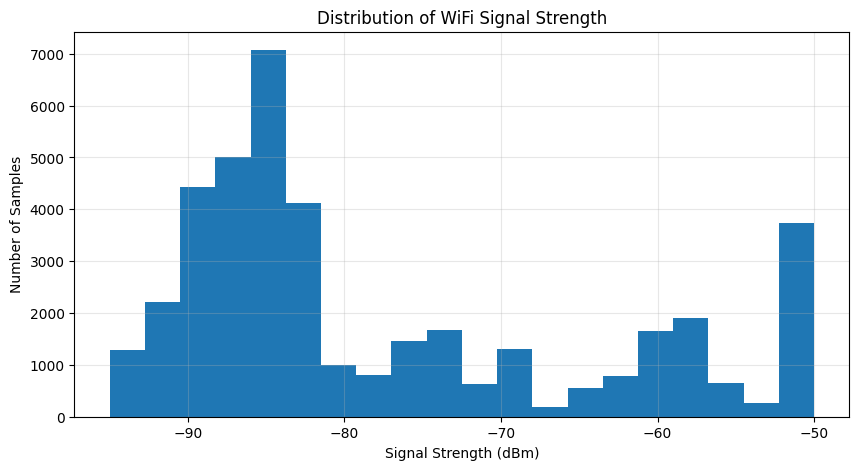

In [18]:
# ==========================================================
# Signal Strength Distribution
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    dataset["signal_strength"],
    bins=20
)

plt.title("Distribution of WiFi Signal Strength")

plt.xlabel("Signal Strength (dBm)")

plt.ylabel("Number of Samples")

plt.grid(alpha=0.3)

plt.show()

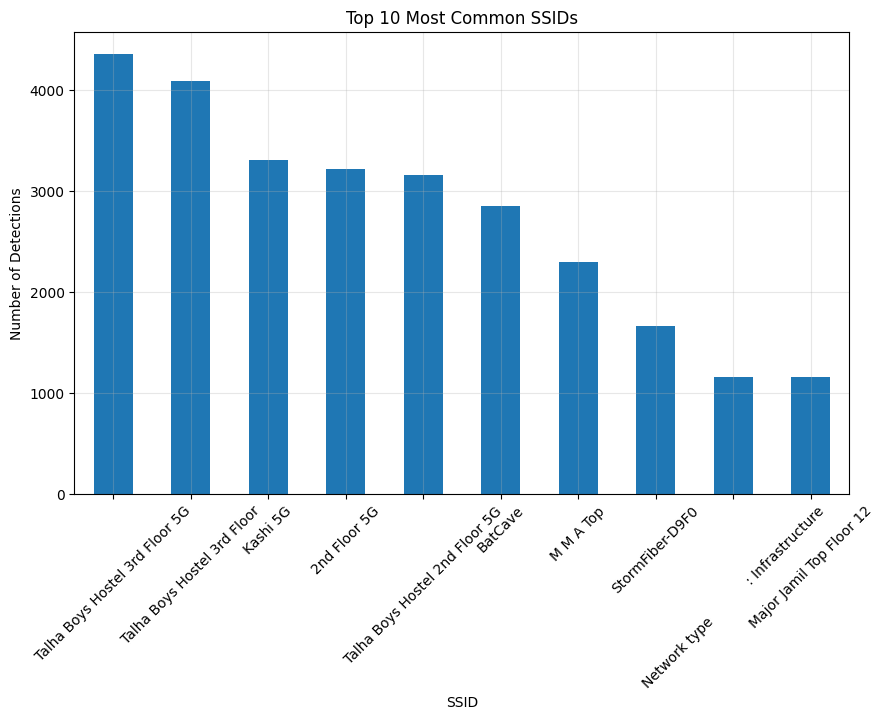

In [19]:
# ==========================================================
# Most Common SSIDs
# ==========================================================

top_ssids = dataset["ssid"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_ssids.plot(kind="bar")

plt.title("Top 10 Most Common SSIDs")

plt.xlabel("SSID")

plt.ylabel("Number of Detections")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

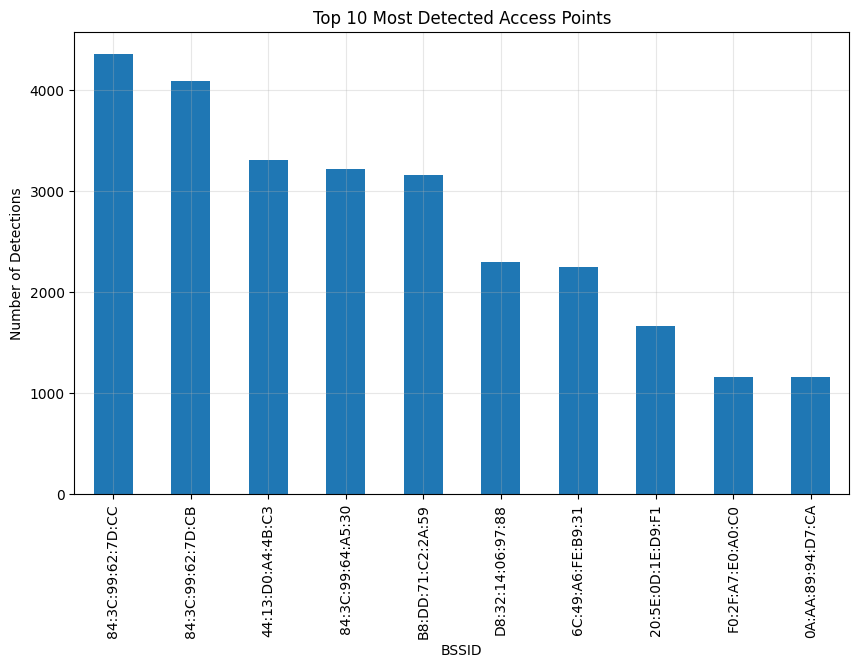

In [20]:
# ==========================================================
# Most Common BSSIDs
# ==========================================================

top_bssid = dataset["bssid"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_bssid.plot(kind="bar")

plt.title("Top 10 Most Detected Access Points")

plt.xlabel("BSSID")

plt.ylabel("Number of Detections")

plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.show()

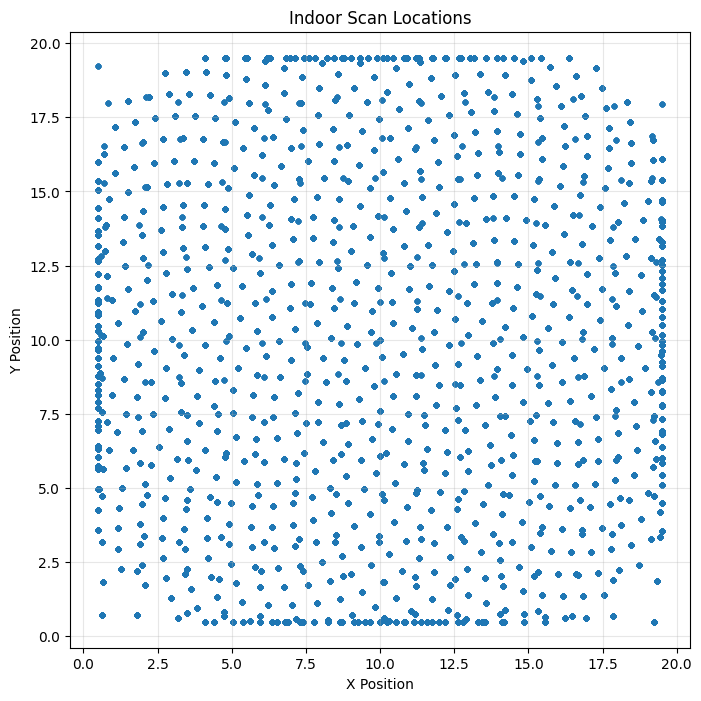

In [21]:
# ==========================================================
# Scan Locations
# ==========================================================

plt.figure(figsize=(8,8))

plt.scatter(
    dataset["x_pos"],
    dataset["y_pos"],
    s=10,
    alpha=0.6
)

plt.title("Indoor Scan Locations")

plt.xlabel("X Position")

plt.ylabel("Y Position")

plt.grid(alpha=0.3)

plt.axis("equal")

plt.show()

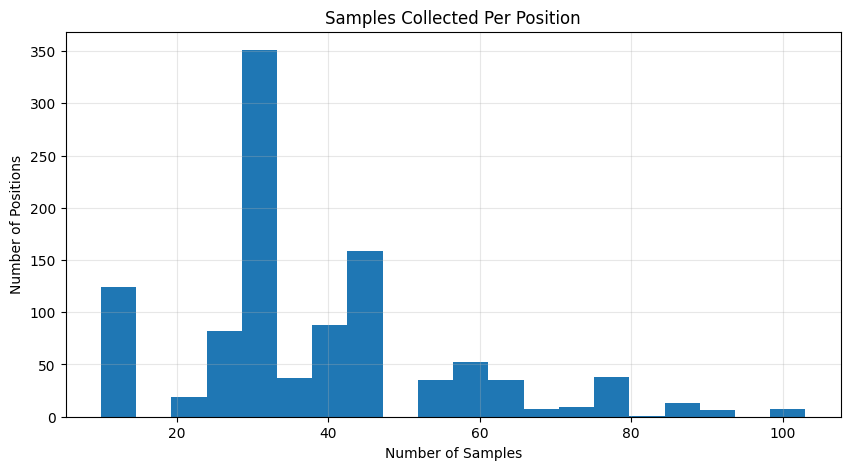

In [22]:
# ==========================================================
# Samples Per Position
# ==========================================================

samples_per_position = (
    dataset
    .groupby(["x_pos","y_pos"])
    .size()
)

plt.figure(figsize=(10,5))

plt.hist(samples_per_position, bins=20)

plt.title("Samples Collected Per Position")

plt.xlabel("Number of Samples")

plt.ylabel("Number of Positions")

plt.grid(alpha=0.3)

plt.show()

In [23]:
print("="*60)
print("EDA SUMMARY")
print("="*60)

print(f"Total Samples        : {len(dataset):,}")

print(f"Unique Positions     : {dataset[['x_pos','y_pos']].drop_duplicates().shape[0]}")

print(f"Unique SSIDs         : {dataset['ssid'].nunique()}")

print(f"Unique BSSIDs        : {dataset['bssid'].nunique()}")

print(f"Average RSSI         : {dataset['signal_strength'].mean():.2f} dBm")

EDA SUMMARY
Total Samples        : 40,783
Unique Positions     : 1063
Unique SSIDs         : 47
Unique BSSIDs        : 49
Average RSSI         : -77.56 dBm
